# 06 — Recurrent Neural Networks and LSTMs

Sequence state, BPTT, gating, and recurrent classifiers from concepts to frameworks.

## Learning objectives

You will learn to:

- explain how an RNN updates and reuses a hidden state;
- understand unrolling and backpropagation through time;
- visualize vanishing and exploding gradients;
- implement a simple RNN forward pass with NumPy;
- derive the role of LSTM gates and cell state;
- build sequence classifiers in PyTorch and Keras;
- connect recurrent modeling ideas to your later transformer studies.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

rng = np.random.default_rng(42)

## 1. Why sequence models need state

In a fixed-window model, each input is processed independently. A recurrent neural network carries a hidden state:

$$
h_t=\tanh(W_{xh}x_t+W_{hh}h_{t-1}+b_h).
$$

An output can be produced at every step:

$$
o_t=W_{hy}h_t+b_y.
$$

The same parameters are reused at every time step. This parameter sharing lets one model process variable-length sequences.

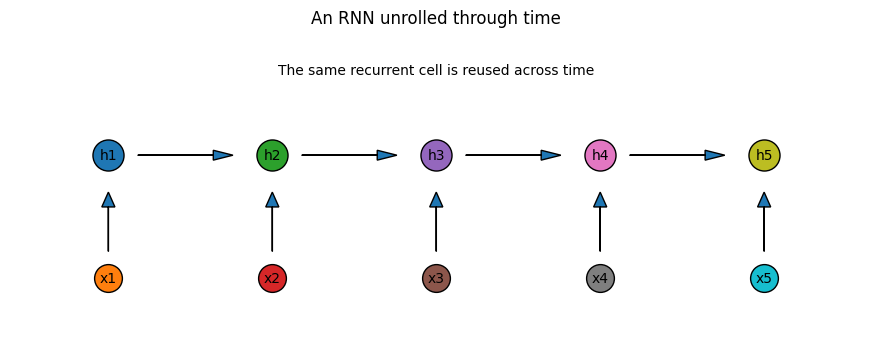

In [2]:
# Draw an unrolled RNN.
T = 5
plt.figure(figsize=(11, 4))
for t in range(T):
    plt.scatter(t, 1, s=500, edgecolor='black')
    plt.text(t, 1, f'h{t+1}', ha='center', va='center')
    plt.scatter(t, 0, s=400, edgecolor='black')
    plt.text(t, 0, f'x{t+1}', ha='center', va='center')
    plt.arrow(t, 0.22, 0, 0.48, head_width=0.08, length_includes_head=True)
    if t < T - 1:
        plt.arrow(t + 0.18, 1, 0.58, 0, head_width=0.08, length_includes_head=True)
plt.text(2, 1.65, 'The same recurrent cell is reused across time', ha='center')
plt.xlim(-0.6, T - 0.4)
plt.ylim(-0.5, 2)
plt.axis('off')
plt.title('An RNN unrolled through time')
plt.show()

## 2. A simple RNN forward pass from scratch

Assume each token is represented by a vector $x_t$. The following implementation processes one sequence and returns every hidden state.

In [3]:
def rnn_forward(inputs, W_xh, W_hh, b_h, h0=None):
    sequence_length = inputs.shape[0]
    hidden_size = W_hh.shape[0]
    h = np.zeros(hidden_size) if h0 is None else h0.copy()
    hidden_states = []

    for t in range(sequence_length):
        h = np.tanh(inputs[t] @ W_xh + h @ W_hh + b_h)
        hidden_states.append(h.copy())
    return np.stack(hidden_states)

sequence_length = 6
input_size = 3
hidden_size = 4
inputs = rng.normal(size=(sequence_length, input_size))
W_xh = rng.normal(scale=0.4, size=(input_size, hidden_size))
W_hh = rng.normal(scale=0.4, size=(hidden_size, hidden_size))
b_h = np.zeros(hidden_size)

hidden_states = rnn_forward(inputs, W_xh, W_hh, b_h)
print('Input shape:', inputs.shape)
print('All hidden states shape:', hidden_states.shape)
print('Final hidden state:', hidden_states[-1])

Input shape: (6, 3)
All hidden states shape: (6, 4)
Final hidden state: [-0.04412106 -0.03591337 -0.21074129 -0.16216722]


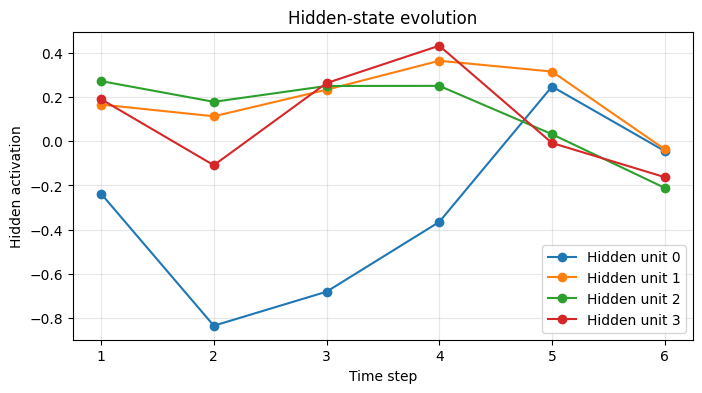

In [4]:
plt.figure(figsize=(8, 4))
for unit in range(hidden_size):
    plt.plot(range(1, sequence_length + 1), hidden_states[:, unit], marker='o', label=f'Hidden unit {unit}')
plt.xlabel('Time step')
plt.ylabel('Hidden activation')
plt.title('Hidden-state evolution')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 3. Backpropagation through time (BPTT)

Unrolling turns the RNN into a deep computation graph whose layers share weights. Gradients from later losses flow backward through many recurrent transitions.

Repeated multiplication by Jacobians can make gradients:

- shrink exponentially: **vanishing gradients**;
- grow exponentially: **exploding gradients**.

This makes long-range dependencies difficult for basic RNNs.

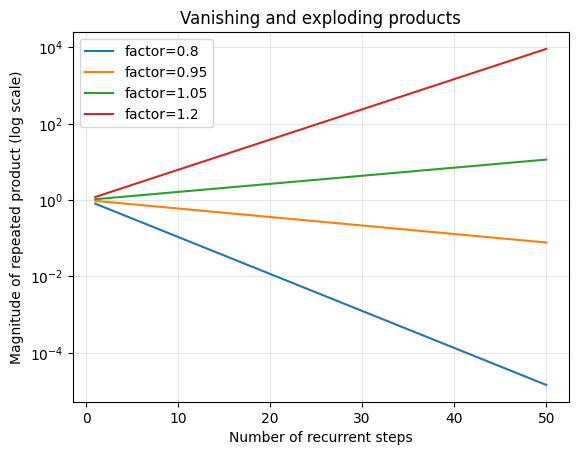

In [5]:
# Scalar intuition: repeated multiplication by one recurrent derivative.
steps = np.arange(1, 51)
for recurrent_factor in [0.8, 0.95, 1.05, 1.2]:
    plt.plot(steps, np.abs(recurrent_factor) ** steps, label=f'factor={recurrent_factor}')
plt.yscale('log')
plt.xlabel('Number of recurrent steps')
plt.ylabel('Magnitude of repeated product (log scale)')
plt.title('Vanishing and exploding products')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Actual gradients also contain activation derivatives and changing matrices, but the repeated-product intuition is accurate. Common mitigations include:

- gated architectures such as LSTM and GRU;
- careful initialization;
- gradient clipping for exploding gradients;
- normalization;
- shorter truncated BPTT windows;
- attention mechanisms.

## 4. LSTM intuition

An LSTM maintains a cell state $c_t$ and hidden state $h_t$.

$$
f_t=\sigma(W_f[x_t,h_{t-1}]+b_f) \quad \text{forget gate}
$$

$$
i_t=\sigma(W_i[x_t,h_{t-1}]+b_i) \quad \text{input gate}
$$

$$
\widetilde c_t=\tanh(W_c[x_t,h_{t-1}]+b_c) \quad \text{candidate}
$$

$$
c_t=f_t\odot c_{t-1}+i_t\odot\widetilde c_t
$$

$$
o_t=\sigma(W_o[x_t,h_{t-1}]+b_o) \quad \text{output gate}
$$

$$
h_t=o_t\odot\tanh(c_t).
$$

The additive cell-state path provides a more direct route for information and gradients than repeated complete overwriting by a simple RNN.

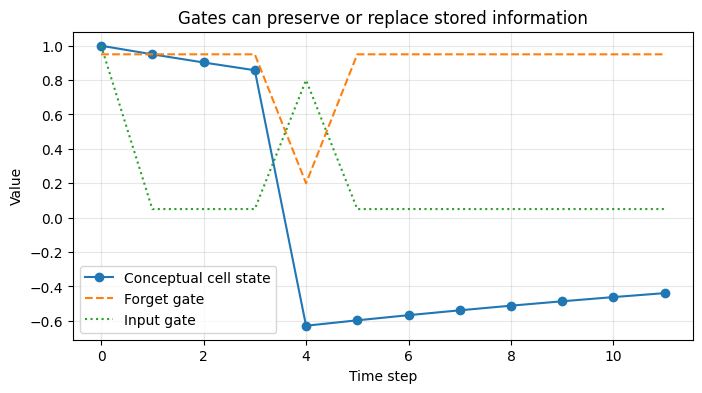

In [6]:
# A conceptual cell-state example, not a trained LSTM.
time = np.arange(12)
forget_gate = np.array([0.95, 0.95, 0.95, 0.95, 0.20, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95])
input_gate = np.array([1.00, 0.05, 0.05, 0.05, 0.80, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05])
candidate = np.array([1.00, 0.00, 0.00, 0.00, -1.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00])
cell = np.zeros_like(time, dtype=float)
previous = 0.0
for t in time:
    previous = forget_gate[t] * previous + input_gate[t] * candidate[t]
    cell[t] = previous

plt.figure(figsize=(8, 4))
plt.plot(time, cell, marker='o', label='Conceptual cell state')
plt.plot(time, forget_gate, linestyle='--', label='Forget gate')
plt.plot(time, input_gate, linestyle=':', label='Input gate')
plt.xlabel('Time step')
plt.ylabel('Value')
plt.title('Gates can preserve or replace stored information')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 5. A toy sequence-classification problem

We generate binary sequences. The label is 1 when the first token equals the last token and 0 otherwise.

This task is intentionally synthetic. It tests whether a model can preserve information from the beginning until the end.

In [7]:
def make_sequence_dataset(n_samples=3000, length=12, seed=42):
    local_rng = np.random.default_rng(seed)
    X = local_rng.integers(0, 2, size=(n_samples, length))
    y = (X[:, 0] == X[:, -1]).astype(np.int64)
    return X, y

X_seq, y_seq = make_sequence_dataset()
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, stratify=y_seq, random_state=42
)
print('Example sequence:', X_train[0], 'label:', y_train[0])
print('Class proportions:', np.bincount(y_train) / len(y_train))

Example sequence: [1 1 0 0 0 0 0 0 1 0 1 1] label: 1
Class proportions: [0.49166667 0.50833333]


## 6. PyTorch RNN and LSTM classifiers

Tokens are mapped to trainable embeddings, processed recurrently, and classified from the final hidden representation.

In [8]:
try:
    import torch
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset

    torch.manual_seed(42)
    Xtr = torch.tensor(X_train, dtype=torch.long)
    ytr = torch.tensor(y_train, dtype=torch.float32)
    Xte = torch.tensor(X_test, dtype=torch.long)

    train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=64, shuffle=True)

    class SequenceClassifier(nn.Module):
        def __init__(self, recurrent_type='lstm', vocab_size=2, embedding_dim=8, hidden_dim=20):
            super().__init__()
            self.embedding = nn.Embedding(vocab_size, embedding_dim)
            if recurrent_type == 'rnn':
                self.recurrent = nn.RNN(embedding_dim, hidden_dim, batch_first=True)
            elif recurrent_type == 'lstm':
                self.recurrent = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
            else:
                raise ValueError("recurrent_type must be 'rnn' or 'lstm'")
            self.output = nn.Linear(hidden_dim, 1)

        def forward(self, token_ids):
            embedded = self.embedding(token_ids)
            sequence_output, state = self.recurrent(embedded)
            final_output = sequence_output[:, -1, :]
            return self.output(final_output).squeeze(1)

    def train_model(model, epochs=10):
        optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
        loss_fn = nn.BCEWithLogitsLoss()
        history = []
        for _ in range(epochs):
            model.train()
            total_loss = 0.0
            for xb, yb in train_loader:
                logits = model(xb)
                loss = loss_fn(logits, yb)
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                total_loss += loss.item() * len(xb)
            history.append(total_loss / len(train_loader.dataset))
        return history

    results = {}
    for model_type in ['rnn', 'lstm']:
        model = SequenceClassifier(recurrent_type=model_type)
        history = train_model(model, epochs=10)
        model.eval()
        with torch.no_grad():
            pred = (torch.sigmoid(model(Xte)).numpy() >= 0.5).astype(int)
        results[model_type] = {'model': model, 'history': history, 'accuracy': accuracy_score(y_test, pred)}
        print(f'{model_type.upper()} test accuracy: {results[model_type]["accuracy"]:.3f}')
except ImportError:
    print('PyTorch is not installed. Install it to run this section.')

RNN test accuracy: 1.000


LSTM test accuracy: 1.000


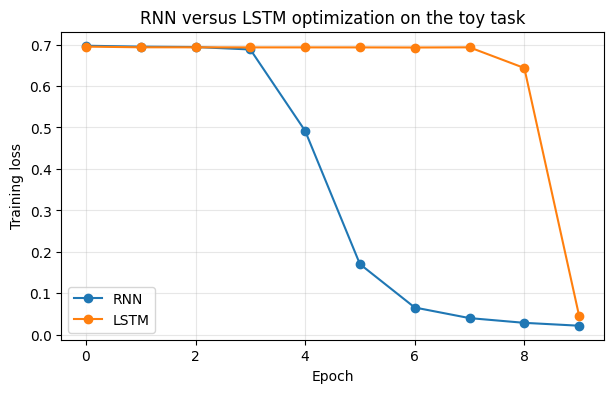

In [9]:
if 'results' in globals():
    plt.figure(figsize=(7, 4))
    for model_type, result in results.items():
        plt.plot(result['history'], marker='o', label=model_type.upper())
    plt.xlabel('Epoch')
    plt.ylabel('Training loss')
    plt.title('RNN versus LSTM optimization on the toy task')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

Do not conclude from one tiny task that LSTMs always beat RNNs. Performance depends on sequence length, data volume, optimization, initialization, and task structure. The comparison is intended to expose the common interface and gated architecture.

## 7. Equivalent Keras models

Keras uses input shape `(batch, timesteps)` before the embedding and `(batch, timesteps, features)` after it.

In [10]:
try:
    import tensorflow as tf

    def build_keras_sequence_model(kind='lstm'):
        recurrent_layer = (
            tf.keras.layers.SimpleRNN(20)
            if kind == 'rnn'
            else tf.keras.layers.LSTM(20)
        )
        model = tf.keras.Sequential([
            tf.keras.layers.Input(shape=(X_train.shape[1],)),
            tf.keras.layers.Embedding(input_dim=2, output_dim=8),
            recurrent_layer,
            tf.keras.layers.Dense(1, activation='sigmoid'),
        ])
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
        return model

    keras_lstm = build_keras_sequence_model('lstm')
    keras_lstm.fit(X_train, y_train, epochs=10, batch_size=64, verbose=0)
    print('Keras LSTM test metrics:', keras_lstm.evaluate(X_test, y_test, verbose=0))
except ImportError:
    print('TensorFlow is optional and is not installed in this environment.')
    print('Install it with: pip install tensorflow')

TensorFlow is optional and is not installed in this environment.
Install it with: pip install tensorflow


## 8. Sequence-output patterns

Common architectures:

- **many-to-one:** sentiment classification; sequence to one label;
- **many-to-many aligned:** POS tagging; one tag per token;
- **encoder-decoder:** one input sequence to a different-length output sequence;
- **autoregressive generation:** predict the next token repeatedly.

For POS tagging, use every recurrent output rather than only the last one.

## 9. From recurrent models toward transformers

RNNs compress the past into a sequentially updated state and are difficult to parallelize across time. Attention lets each position directly combine information from other positions. Transformers replace recurrence with attention, feed-forward blocks, residual connections, and positional information.

The recurrent concepts remain useful for understanding:

- sequence probability factorization;
- token embeddings;
- hidden representations;
- gradient flow;
- masking and variable lengths;
- sequence classification versus token classification.

These foundations will make later BERT fine-tuning substantially easier.

## Exercises

1. Implement an RNN cell backward pass for one time step, then extend it through time.
2. Create a longer-memory task and compare RNN and LSTM as length increases.
3. Use every output to solve a token-level labeling problem.
4. Add padding and sequence lengths, then use PyTorch packed sequences.
5. Build a character-level next-token model.
6. Compare final-state classification with mean pooling over all hidden states.
7. Implement a GRU cell from its equations.

## Key takeaways

- RNNs reuse one transition function over sequence positions.
- BPTT differentiates through the unrolled computation graph.
- Repeated Jacobian products cause vanishing or exploding gradients.
- LSTM gates regulate memory updates and create a more direct cell-state path.
- Framework recurrent layers hide low-level differentiation but not data and shape decisions.
- Recurrent modeling provides a strong conceptual bridge to transformer-based NLP.